In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
import cv2
from tensorflow.keras import layers, models

In [11]:
dataset, info = tfds.load('oxford_iiit_pet:4.*.*', with_info=True)

In [12]:
train_data = dataset['train']
test_data = dataset['test']

In [4]:
IMG_SIZE = 128
BATCH_SIZE = 16
# preprocessing (resizing and scaling)

In [13]:
def preprocess(data):
    image = data['image']
    mask = data['segmentation_mask']
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    mask = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE))
    print(mask)
    image = tf.cast(image, tf.float32) / 255.0
    return image, mask

In [14]:
train_data = train_data.map(preprocess).cache().shuffle(1000).batch(BATCH_SIZE)

Tensor("resize_1/Squeeze:0", shape=(128, 128, 1), dtype=float32)


(16, 128, 128, 3)
(16, 128, 128, 1)


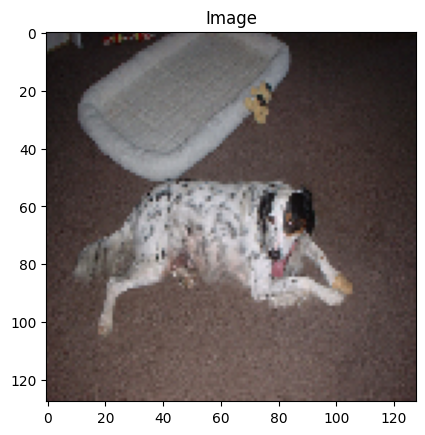

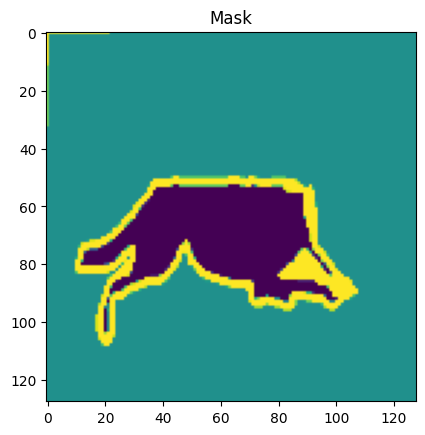

In [15]:
for images, masks in train_data.take(1):
    print(images.shape)
    print(masks.shape)
    plt.title('Image')
    plt.imshow(images[0])
    plt.figure()
    plt.title('Mask')
    plt.imshow(masks[0])

In [5]:
def conv_block(x,num_filters):
    x = layers.Conv2D(num_filters, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(num_filters, 3, padding='same', activation='relu')(x)
    return x

In [6]:
def encoder_block(x,num_filters):
    f = conv_block(x,num_filters)
    p = layers.MaxPool2D((2,2))(f)
    return f,p

In [7]:
def decoder_block(x, skip_features, num_filters):
    x = layers.Conv2DTranspose(num_filters, (2,2), strides=2, padding='same')(x)
    x = layers.Concatenate()([x, skip_features])
    x = conv_block(x,num_filters)
    return x

In [8]:
def build_unet(input_shape):
    inputs = layers.Input(input_shape)

    # Encoder
    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    # Bottleneck
    b1 = conv_block(p4, 1024)

    # Decoder
    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    outputs = layers.Conv2D(1, (1,1), padding='same', activation='sigmoid')(d4)

    model = models.Model(inputs, outputs)
    return model

In [9]:
scratch_modl=build_unet((IMG_SIZE, IMG_SIZE, 3))
scratch_modl.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 512) │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8,      │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 8, 8,      │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │  2,097,664 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_transpose

 Total params: 31,031,745 (118.38 MB)

 Trainable params: 31,031,745 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
scratch_modl.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])    

In [16]:
EPOCHS = 5
history = scratch_modl.fit(train_data, epochs=EPOCHS)   

Epoch 1/5
230/230 ━━━━━━━━━━━━━━━━━━━━ 85s 192ms/step - accuracy: 0.0850 - loss: nan
Epoch 2/5
230/230 ━━━━━━━━━━━━━━━━━━━━ 44s 192ms/step - accuracy: 0.0000e+00 - loss: nan
Epoch 3/5
230/230 ━━━━━━━━━━━━━━━━━━━━ 45s 195ms/step - accuracy: 0.0000e+00 - loss: nan
Epoch 4/5
230/230 ━━━━━━━━━━━━━━━━━━━━ 45s 197ms/step - accuracy: 0.0000e+00 - loss: nan
Epoch 5/5
230/230 ━━━━━━━━━━━━━━━━━━━━ 45s 196ms/step - accuracy: 0.0000e+00 - loss: nan
